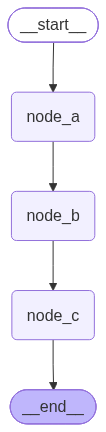

2026-08-14 18:39:44.183 | INFO     | __main__:<module>:50 - ==========-> 第一次执行 <-==========
2026-08-14 18:39:44.188 | INFO     | __main__:<module>:57 - 第一次执行结果：None
2026-08-14 18:39:44.189 | INFO     | __main__:<module>:59 - ==========-> 第二次执行 <-==========
2026-08-14 18:39:44.189 | INFO     | __main__:node_a:11 - node_a 被执行
2026-08-14 18:39:44.191 | INFO     | __main__:<module>:66 - 第二次执行结果：{'final_res': 'node_a 运行的中间结果'}
2026-08-14 18:39:44.191 | INFO     | __main__:<module>:68 - ==========-> 第三次执行 <-==========
2026-08-14 18:39:44.192 | INFO     | __main__:node_b:17 - node_b 被执行
2026-08-14 18:39:44.193 | INFO     | __main__:node_c:23 - node_c 被执行
2026-08-14 18:39:44.194 | INFO     | __main__:<module>:70 - 第三次执行结果：{'final_res': 'node_c 运行的中间结果'}
2026-08-14 18:39:44.195 | INFO     | __main__:<module>:72 - ==========-> 第四次执行 <-==========
2026-08-14 18:39:44.195 | INFO     | __main__:<module>:74 - 第四次执行结果：{'final_res': 'node_c 运行的中间结果'}
2026-08-14 18:39:44.196 | INFO     | __main__:<modul

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_a(node_a)
	node_b(node_b)
	node_c(node_c)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_a;
	node_a --> node_b;
	node_b --> node_c;
	node_c --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

from loguru import logger

class OverAllState(TypedDict):
    final_res: str

def node_a(state: OverAllState) -> OverAllState:
    logger.info("node_a 被执行")
    return {
        "final_res": "node_a 运行的中间结果"
    }

def node_b(state: OverAllState) -> OverAllState:
    logger.info("node_b 被执行")
    return {
        "final_res": "node_b 运行的中间结果"
    }

def node_c(state: OverAllState) -> OverAllState:
    logger.info("node_c 被执行")
    return {
        "final_res": "node_c 运行的中间结果"
    }


builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", "node_c")
builder.add_edge("node_c", END)

checkpointer = InMemorySaver()
graph = builder.compile(
    checkpointer=checkpointer
)

from IPython.display import display
display(graph)
raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)
config = {"configurable": {"thread_id": "123"}}

logger.info("{}-> 第一次执行 <-{}", "=" * 10, "=" * 10)
first_res = graph.invoke(
    {},
    config=config,
    interrupt_before=["node_a", "node_b"],
    interrupt_after=["node_a", "node_b"]
)
logger.info("第一次执行结果：{}", first_res)

logger.info("{}-> 第二次执行 <-{}", "=" * 10, "=" * 10)
second_res = graph.invoke(
    None,
    config=config,
    interrupt_before=["node_a", "node_b"],
    interrupt_after=["node_a", "node_b"]
)
logger.info("第二次执行结果：{}", second_res)

logger.info("{}-> 第三次执行 <-{}", "=" * 10, "=" * 10)
third_res = graph.invoke(None, config=config)
logger.info("第三次执行结果：{}", third_res)

logger.info("{}-> 第四次执行 <-{}", "=" * 10, "=" * 10)
final_res = graph.invoke(None, config=config)
logger.info("第四次执行结果：{}", final_res)

logger.info("{}-> 完毕 <-{}", "=" * 10, "=" * 10)